#### **Phase 0: Environment Setup**

 Snippet 1 — Imports + mount Google Drive

 Snippet 1b — Correct BASE_PATH

 Snippet 1c — Peek at folder structure

 Snippet 2 — Image loader + label assignment

### Imports + Mount Google Drive

In [1]:
# ── Snippet 1: Imports & Google Drive Setup ──────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from scipy.spatial.distance import mahalanobis
from scipy import linalg

from google.colab import drive
import os

In [2]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
BASE_PATH = '/content/drive/MyDrive/Zero Shot Anomaly Detection/Data/archive'
CATEGORIES = ['carpet', 'hazelnut', 'screw']

# Confirm again
for cat in CATEGORIES:
    cat_path = os.path.join(BASE_PATH, cat)
    print(f"[OK] {cat_path}")
    # Also peek at what files/subfolders are inside
    contents = os.listdir(cat_path)
    print(f"     Contents: {contents}\n")

[OK] /content/drive/MyDrive/Zero Shot Anomaly Detection/Data/archive/carpet
     Contents: ['readme.txt', 'license.txt', 'ground_truth', 'test', 'train']

[OK] /content/drive/MyDrive/Zero Shot Anomaly Detection/Data/archive/hazelnut
     Contents: ['readme.txt', 'license.txt', 'test', 'train', 'ground_truth']

[OK] /content/drive/MyDrive/Zero Shot Anomaly Detection/Data/archive/screw
     Contents: ['license.txt', 'readme.txt', 'ground_truth', 'train', 'test']



In [6]:
# ── Snippet 1c: Peek inside train/ and test/ ──────────────────────────────────

for cat in CATEGORIES:
    print(f"\n{'='*40}")
    print(f"Category: {cat}")

    train_path = os.path.join(BASE_PATH, cat, 'train')
    test_path  = os.path.join(BASE_PATH, cat, 'test')

    print(f"  train/ subfolders: {os.listdir(train_path)}")
    print(f"  test/  subfolders: {os.listdir(test_path)}")

    # Count images in each test subfolder
    print(f"  test/ breakdown:")
    for subfolder in sorted(os.listdir(test_path)):
        sub_path = os.path.join(test_path, subfolder)
        if os.path.isdir(sub_path):
            n = len(os.listdir(sub_path))
            print(f"    [{subfolder}]: {n} images")


Category: carpet
  train/ subfolders: ['good']
  test/  subfolders: ['cut', 'metal_contamination', 'hole', 'good', 'color', 'thread']
  test/ breakdown:
    [color]: 19 images
    [cut]: 17 images
    [good]: 28 images
    [hole]: 17 images
    [metal_contamination]: 17 images
    [thread]: 19 images

Category: hazelnut
  train/ subfolders: ['good']
  test/  subfolders: ['crack', 'good', 'cut', 'hole', 'print']
  test/ breakdown:
    [crack]: 18 images
    [cut]: 17 images
    [good]: 40 images
    [hole]: 18 images
    [print]: 17 images

Category: screw
  train/ subfolders: ['good']
  test/  subfolders: ['good', 'manipulated_front', 'scratch_neck', 'scratch_head', 'thread_side', 'thread_top']
  test/ breakdown:
    [good]: 41 images
    [manipulated_front]: 24 images
    [scratch_head]: 24 images
    [scratch_neck]: 25 images
    [thread_side]: 23 images
    [thread_top]: 23 images


In [10]:
# ── Snippet 1d: Dynamic Category Selector ────────────────────────────────────

import os

BASE_PATH = '/content/drive/MyDrive/Zero Shot Anomaly Detection/Data/archive'

# ── Auto-detect all available categories from the dataset ────────────────────
ALL_CATEGORIES = sorted([
    d for d in os.listdir(BASE_PATH)
    if os.path.isdir(os.path.join(BASE_PATH, d))
    and 'train' in os.listdir(os.path.join(BASE_PATH, d))  # valid category folders only
])

print("=" * 50)
print("Available MVTec AD Categories:")
print("=" * 50)
for i, cat in enumerate(ALL_CATEGORIES):
    train_count = len(os.listdir(os.path.join(BASE_PATH, cat, 'train', 'good')))
    print(f"  [{i:2d}] {cat:<20} ({train_count} training images)")

print("=" * 50)

# ── User Selection ────────────────────────────────────────────────────────────
print("\nOptions:")
print("  • Type 'all'            → use all categories")
print("  • Type indices          → e.g. 0,3,7")
print("  • Type category names   → e.g. carpet,screw,hazelnut")

user_input = input("\nYour selection: ").strip().lower()

if user_input == 'all':
    CATEGORIES = ALL_CATEGORIES

elif user_input.replace(',', '').replace(' ', '').isdigit() or \
     all(part.strip().isdigit() for part in user_input.split(',')):
    # Index-based selection
    indices = [int(i.strip()) for i in user_input.split(',')]
    CATEGORIES = [ALL_CATEGORIES[i] for i in indices]

else:
    # Name-based selection with fuzzy matching (handles spaces, caps, underscores)
    def normalize(s):
        return s.strip().lower().replace(' ', '_').replace('-', '_')

    requested = [c.strip() for c in user_input.split(',')]
    norm_map  = {normalize(c): c for c in ALL_CATEGORIES}

    CATEGORIES = []
    invalid    = []
    for r in requested:
        matched = norm_map.get(normalize(r))
        if matched:
            CATEGORIES.append(matched)
        else:
            invalid.append(r)

    if invalid:
        print(f"\n  Ignored unrecognized categories: {invalid}")

# ── Confirm final selection ───────────────────────────────────────────────────
print("\n" + "=" * 50)
print(f"Running pipeline on {len(CATEGORIES)} categorie(s):")
for cat in CATEGORIES:
    train_count = len(os.listdir(os.path.join(BASE_PATH, cat, 'train', 'good')))
    print(f"   • {cat:<20} ({train_count} training images)")
print("=" * 50)

Available MVTec AD Categories:
  [ 0] bottle               (209 training images)
  [ 1] cable                (224 training images)
  [ 2] capsule              (219 training images)
  [ 3] carpet               (280 training images)
  [ 4] grid                 (264 training images)
  [ 5] hazelnut             (391 training images)
  [ 6] leather              (245 training images)
  [ 7] metal_nut            (220 training images)
  [ 8] pill                 (267 training images)
  [ 9] screw                (320 training images)
  [10] tile                 (230 training images)
  [11] toothbrush           (60 training images)
  [12] transistor           (213 training images)
  [13] wood                 (247 training images)
  [14] zipper               (240 training images)

Options:
  • Type 'all'            → use all categories
  • Type indices          → e.g. 0,3,7
  • Type category names   → e.g. carpet,screw,hazelnut

Your selection: bottle

Running pipeline on 1 categorie(s):
   • bot

#### **Phase 1: Deep Feature Extraction**

 Snippet 3 — Load pretrained ResNet50, strip the classification head, set to eval mode

 Snippet 4 — Extract feature vectors from all train and test images (forward pass, no gradients)

 Snippet 5 — Save extracted features to Drive (so you never re-run the slow CNN step again)

#### Snippet 3 — Load pretrained ResNet50, strip the classification head, set to eval mode

In [11]:
# ── Snippet 3: ResNet50 Feature Extractor ────────────────────────────────────

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader

# ── Device Setup ──────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── Load Pretrained ResNet50 ──────────────────────────────────────────────────
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Strip the final classification head — we want features, not class predictions
# ResNet50 architecture: conv layers → avgpool → fc (classifier)
# We remove the fc layer, keeping everything up to avgpool
feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()  # IMPORTANT: disables dropout/batchnorm randomness

print(f"ResNet50 loaded ✅")
print(f"Output feature size per image: 2048-dimensional vector")

# ── Image Preprocessing ───────────────────────────────────────────────────────
# Must match ImageNet stats that ResNet50 was trained on
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── Custom Dataset Class ──────────────────────────────────────────────────────
class ImageFolderFlat(Dataset):
    """Loads all images from a flat folder (no subfolders)."""
    def __init__(self, folder_path, transform=None):
        self.transform  = transform
        self.image_paths = sorted([
            os.path.join(folder_path, f)
            for f in os.listdir(folder_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

# ── Feature Extraction Function ───────────────────────────────────────────────
def extract_features(folder_path, batch_size=32):
    """
    Extracts 2048-dim ResNet50 features for all images in a folder.
    Returns: np.array of shape (N, 2048)
    """
    dataset    = ImageFolderFlat(folder_path, transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size,
                            shuffle=False, num_workers=2)

    all_features = []

    with torch.no_grad():  # no gradients needed — saves memory
        for batch in dataloader:
            batch    = batch.to(device)
            features = feature_extractor(batch)         # (B, 2048, 1, 1)
            features = features.squeeze(-1).squeeze(-1) # (B, 2048)
            all_features.append(features.cpu().numpy())

    return np.concatenate(all_features, axis=0)         # (N, 2048)

# ── Quick Verification ────────────────────────────────────────────────────────
print("\nVerifying extractor on first category...")
test_cat   = CATEGORIES[0]
train_path = os.path.join(BASE_PATH, test_cat, 'train', 'good')
sample_features = extract_features(train_path)

print(f"Category       : {test_cat}")
print(f"Images found   : {sample_features.shape[0]}")
print(f"Feature dims   : {sample_features.shape[1]}")
print(f"Feature sample (first image, first 5 dims): "
      f"{sample_features[0, :5].round(4)}")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 245MB/s]


ResNet50 loaded ✅
Output feature size per image: 2048-dimensional vector

Verifying extractor on first category...
Category       : bottle
Images found   : 209
Feature dims   : 2048
Feature sample (first image, first 5 dims): [0.936  0.4592 0.081  0.0504 1.5136]




---

**What this does and why:**

- **Stripping the `fc` layer** (`[:-1]`) is the key move — instead of getting a 1000-class probability vector, you get a raw 2048-dimensional feature vector that encodes *what the image looks like* without any classification bias
- **`eval()` mode** is critical — without it, BatchNorm layers behave randomly during inference, giving you different features each run
- **`torch.no_grad()`** disables gradient tracking — you're not training anything, so this saves significant memory and speeds up extraction
- **`DataLoader` with `batch_size=32`** processes images in batches rather than one by one — much faster, especially on GPU
- The output is a plain **numpy array** — framework-agnostic, so your teammates can load it directly for OC-SVM and Isolation Forest without needing PyTorch

---

**Expected output:**
```
Using device: cuda   (or cpu if no GPU)
ResNet50 loaded ✅
Output feature size per image: 2048-dimensional vector

Verifying extractor on first category...
Category       : bottle
Images found   : 209
Feature dims   : 2048

#### Snippet 4: Extract + Save Features for All Selected Categories

In [13]:
# ── Snippet 4: Extract + Save Features for All Categories ────────────────────

import time

# ── Where to save features on Drive ──────────────────────────────────────────
FEATURES_PATH = os.path.join(
    '/content/drive/MyDrive/Zero Shot Anomaly Detection',
    'extracted_features'
)
os.makedirs(FEATURES_PATH, exist_ok=True)
print(f"Features will be saved to: {FEATURES_PATH}\n")

# ── Per-category extraction loop ──────────────────────────────────────────────
def extract_and_save_category(base_path, category, features_path):
    """
    For a given category:
      - Extracts train features (normal only)
      - Extracts test features  (normal + anomalous)
      - Builds test labels      (0=normal, 1=anomalous)
      - Saves all three as .npy files to Drive
    Returns: train_feats, test_feats, test_labels
    """
    cat_save_dir = os.path.join(features_path, category)
    os.makedirs(cat_save_dir, exist_ok=True)

    save_train  = os.path.join(cat_save_dir, 'train_features.npy')
    save_test   = os.path.join(cat_save_dir, 'test_features.npy')
    save_labels = os.path.join(cat_save_dir, 'test_labels.npy')

    # ── Check if already extracted (skip if so) ───────────────────────────────
    if all(os.path.exists(p) for p in [save_train, save_test, save_labels]):
        print(f"  [{category}] Already extracted — loading from Drive...")
        train_feats  = np.load(save_train)
        test_feats   = np.load(save_test)
        test_labels  = np.load(save_labels)
        return train_feats, test_feats, test_labels

    # ── Extract train features ────────────────────────────────────────────────
    print(f"  [{category}] Extracting train features...")
    train_folder = os.path.join(base_path, category, 'train', 'good')
    train_feats  = extract_features(train_folder)

    # ── Extract test features + build labels ──────────────────────────────────
    print(f"  [{category}] Extracting test features...")
    test_root       = os.path.join(base_path, category, 'test')
    all_test_feats  = []
    all_test_labels = []

    for subfolder in sorted(os.listdir(test_root)):
        sub_path = os.path.join(test_root, subfolder)
        if not os.path.isdir(sub_path):
            continue

        feats = extract_features(sub_path)
        label = 0 if subfolder == 'good' else 1
        all_test_feats.append(feats)
        all_test_labels.append(np.full(len(feats), label, dtype=int))
        print(f"    └─ {subfolder:<25} {len(feats):>3} images  label={label}")

    test_feats  = np.concatenate(all_test_feats,  axis=0)
    test_labels = np.concatenate(all_test_labels, axis=0)

    # ── Save to Drive ─────────────────────────────────────────────────────────
    np.save(save_train,  train_feats)
    np.save(save_test,   test_feats)
    np.save(save_labels, test_labels)
    print(f"  [{category}] Saved to Drive")

    return train_feats, test_feats, test_labels


# ── Run for all selected categories ───────────────────────────────────────────
all_features = {}   # stores everything in memory for downstream steps

total_start = time.time()

for cat in CATEGORIES:
    print(f"\n{'='*50}")
    print(f"Processing: {cat.upper()}")
    print(f"{'='*50}")
    start = time.time()

    train_feats, test_feats, test_labels = extract_and_save_category(
        BASE_PATH, cat, FEATURES_PATH
    )

    all_features[cat] = {
        'train': train_feats,
        'test' : test_feats,
        'labels': test_labels
    }

    elapsed = time.time() - start
    print(f"\n  Summary for {cat}:")
    print(f"    Train features : {train_feats.shape}")
    print(f"    Test  features : {test_feats.shape}")
    print(f"    Test  labels   : {test_labels.shape} "
          f"| normal={np.sum(test_labels==0)} "
          f"anomalous={np.sum(test_labels==1)}")
    print(f"    Time taken     : {elapsed:.1f}s")

print(f"\n{'='*50}")
print(f"All categories processed!")
print(f"Total time: {time.time() - total_start:.1f}s")
print(f"{'='*50}")

Features will be saved to: /content/drive/MyDrive/Zero Shot Anomaly Detection/extracted_features


Processing: BOTTLE
  [bottle] Extracting train features...
  [bottle] Extracting test features...
    └─ broken_large               20 images  label=1
    └─ broken_small               22 images  label=1
    └─ contamination              21 images  label=1
    └─ good                       20 images  label=0
  [bottle] Saved to Drive

  Summary for bottle:
    Train features : (209, 2048)
    Test  features : (83, 2048)
    Test  labels   : (83,) | normal=20 anomalous=63
    Time taken     : 6.9s

All categories processed!
Total time: 6.9s


#### Snippet 5 — Save extracted features to Drive (so you never re-run the slow CNN step again)


PCA: BOTTLE


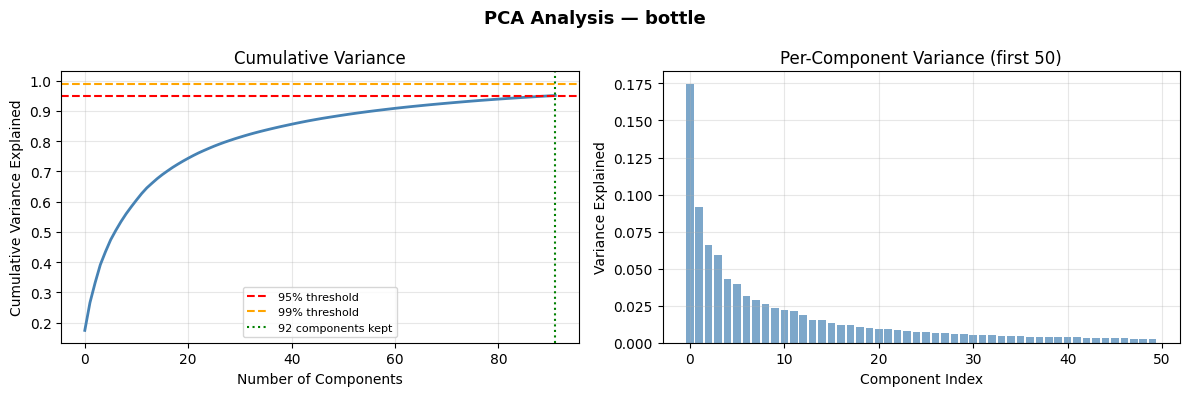

  Original dims : 2048
  Components kept: 92  (95% variance retained)
  Compression ratio: 22.3x

  Train PCA shape : (209, 92)
  Test  PCA shape : (83, 92)


In [14]:
# ── Snippet 5: PCA Dimensionality Reduction ───────────────────────────────────

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ── PCA Configuration ─────────────────────────────────────────────────────────
# We keep enough components to explain 95% of variance
# This is your "Latency Optimization" experiment from the proposal
VARIANCE_THRESHOLD = 0.95   # <-- easy to change to 0.90, 0.99 etc.

def fit_pca_on_train(train_feats, variance_threshold=0.95):
    """
    1. Standardizes features (zero mean, unit variance)
    2. Fits PCA on training data only
    3. Returns scaler, pca, and reduced train features

    IMPORTANT: Fit only on train, transform both train and test
               Fitting on test = data leakage
    """
    # Step 1: Standardize — PCA is sensitive to feature scale
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_feats)  # fit + transform on train

    # Step 2: Fit PCA on training data only
    pca = PCA(n_components=variance_threshold, svd_solver='full')
    train_pca = pca.fit_transform(train_scaled)

    return scaler, pca, train_pca


def apply_pca_to_test(test_feats, scaler, pca):
    """
    Applies the ALREADY FITTED scaler and PCA to test data.
    Never re-fits — just transforms.
    """
    test_scaled = scaler.transform(test_feats)   # transform only, no fit
    test_pca    = pca.transform(test_scaled)
    return test_pca


def plot_variance_explained(pca, category):
    """Scree plot — shows cumulative variance vs number of components."""
    cumvar = np.cumsum(pca.explained_variance_ratio_)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'PCA Analysis — {category}', fontsize=13, fontweight='bold')

    # Left: cumulative variance
    axes[0].plot(cumvar, color='steelblue', linewidth=2)
    axes[0].axhline(y=0.95, color='red',    linestyle='--', label='95% threshold')
    axes[0].axhline(y=0.99, color='orange', linestyle='--', label='99% threshold')
    axes[0].axvline(x=pca.n_components_ - 1, color='green',
                    linestyle=':', label=f'{pca.n_components_} components kept')
    axes[0].set_xlabel('Number of Components')
    axes[0].set_ylabel('Cumulative Variance Explained')
    axes[0].set_title('Cumulative Variance')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Right: individual component variance (first 50 only for readability)
    axes[1].bar(range(min(50, pca.n_components_)),
                pca.explained_variance_ratio_[:50],
                color='steelblue', alpha=0.7)
    axes[1].set_xlabel('Component Index')
    axes[1].set_ylabel('Variance Explained')
    axes[1].set_title('Per-Component Variance (first 50)')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f"  Original dims : 2048")
    print(f"  Components kept: {pca.n_components_}  "
          f"({variance_threshold*100:.0f}% variance retained)")
    print(f"  Compression ratio: {2048/pca.n_components_:.1f}x\n")


# ── Run PCA for all selected categories ───────────────────────────────────────
variance_threshold = VARIANCE_THRESHOLD

pca_results = {}   # stores scaler, pca, reduced features per category

for cat in CATEGORIES:
    print(f"\n{'='*50}")
    print(f"PCA: {cat.upper()}")
    print(f"{'='*50}")

    train_feats = all_features[cat]['train']
    test_feats  = all_features[cat]['test']

    # Fit on train only
    scaler, pca, train_pca = fit_pca_on_train(train_feats, variance_threshold)

    # Apply to test (no re-fitting)
    test_pca = apply_pca_to_test(test_feats, scaler, pca)

    # Store everything
    pca_results[cat] = {
        'scaler'    : scaler,
        'pca'       : pca,
        'train_pca' : train_pca,
        'test_pca'  : test_pca,
        'labels'    : all_features[cat]['labels']
    }

    # Plot + print summary
    plot_variance_explained(pca, cat)
    print(f"  Train PCA shape : {train_pca.shape}")
    print(f"  Test  PCA shape : {test_pca.shape}")


### **Phase 2: Dimensionality Reduction**

 Snippet 6 — Fit PCA on training features only (never on test — that would be data leakage)

 Snippet 7 — Transform both train and test features using the fitted PCA

 Snippet 8 — Variance explained plot (scree plot) to justify how many components to keep

#### Snippet 6 — Fit PCA on training features only (never on test — that would be data leakage)


GMM: BOTTLE
  Fitting GMMs for k = 1 to 10...


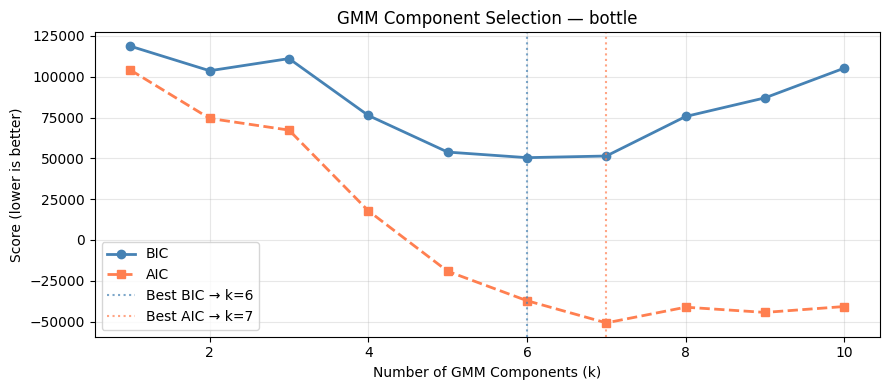

  Best k by BIC : 6
  Best k by AIC : 7
  → Using k = 6 (BIC is preferred: penalizes complexity more strongly)

  Fitting final GMM with k=6...
  GMM fitted 
  Components     : 6
  Converged      : True
  Log-likelihood : 221.2619


In [16]:
# ── Snippet 6: GMM Fitting + Component Selection ──────────────────────────────

from sklearn.mixture import GaussianMixture

# ── Why BIC/AIC? ──────────────────────────────────────────────────────────────
# GMM requires you to choose number of Gaussian components (k)
# Too few  → underfits the normal distribution (misses modes)
# Too many → overfits, treats noise as structure
# BIC/AIC are information criteria that penalize complexity
# Lower BIC/AIC = better model

def select_gmm_components(train_pca, category, k_range=range(1, 11)):
    """
    Fits GMMs with different numbers of components.
    Plots BIC and AIC curves to guide component selection.
    Returns the optimal k based on lowest BIC.
    """
    bic_scores = []
    aic_scores = []
    k_values   = list(k_range)

    print(f"  Fitting GMMs for k = {k_values[0]} to {k_values[-1]}...")

    for k in k_values:
        gmm = GaussianMixture(
            n_components    = k,
            covariance_type = 'full',   # full covariance matrix per component
            random_state    = 42,
            max_iter        = 200,
            n_init          = 3         # run 3 times, keep best
        )
        gmm.fit(train_pca)
        bic_scores.append(gmm.bic(train_pca))
        aic_scores.append(gmm.aic(train_pca))

    # ── Plot BIC / AIC ────────────────────────────────────────────────────────
    best_k_bic = k_values[np.argmin(bic_scores)]
    best_k_aic = k_values[np.argmin(aic_scores)]

    plt.figure(figsize=(9, 4))
    plt.plot(k_values, bic_scores, 'o-', color='steelblue',
             linewidth=2, label='BIC')
    plt.plot(k_values, aic_scores, 's--', color='coral',
             linewidth=2, label='AIC')
    plt.axvline(x=best_k_bic, color='steelblue', linestyle=':',
                alpha=0.7, label=f'Best BIC → k={best_k_bic}')
    plt.axvline(x=best_k_aic, color='coral',     linestyle=':',
                alpha=0.7, label=f'Best AIC → k={best_k_aic}')
    plt.xlabel('Number of GMM Components (k)')
    plt.ylabel('Score (lower is better)')
    plt.title(f'GMM Component Selection — {category}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"  Best k by BIC : {best_k_bic}")
    print(f"  Best k by AIC : {best_k_aic}")
    print(f"  → Using k = {best_k_bic} (BIC is preferred: "
          f"penalizes complexity more strongly)\n")

    return best_k_bic, bic_scores, aic_scores


def fit_gmm(train_pca, n_components):
    """
    Fits final GMM on training (normal) data with chosen k.
    covariance_type='full' means each Gaussian has its own
    full covariance matrix — captures feature correlations properly.
    """
    gmm = GaussianMixture(
        n_components    = n_components,
        covariance_type = 'full',
        random_state    = 42,
        max_iter        = 200,
        n_init          = 5      # more inits for final model = more stable
    )
    gmm.fit(train_pca)

    print(f"  GMM fitted ")
    print(f"  Components     : {gmm.n_components}")
    print(f"  Converged      : {gmm.converged_}")
    print(f"  Log-likelihood : {gmm.lower_bound_:.4f}")

    return gmm


# ── Run for all selected categories ───────────────────────────────────────────
gmm_results = {}   # stores fitted GMM per category

for cat in CATEGORIES:
    print(f"\n{'='*50}")
    print(f"GMM: {cat.upper()}")
    print(f"{'='*50}")

    train_pca = pca_results[cat]['train_pca']

    # Step 1: Find best number of components
    best_k, bic_scores, aic_scores = select_gmm_components(
        train_pca,
        cat,
        k_range=range(1, 11)
    )

    # Step 2: Fit final GMM with best k
    print(f"  Fitting final GMM with k={best_k}...")
    gmm = fit_gmm(train_pca, best_k)

    # Store
    gmm_results[cat] = {
        'gmm'        : gmm,
        'best_k'     : best_k,
        'bic_scores' : bic_scores,
        'aic_scores' : aic_scores
    }

#### Snippet 7: Mahalanobis Distance Scoring

In [17]:
# ── Snippet 7: Mahalanobis Distance Scoring ───────────────────────────────────

from scipy.spatial.distance import mahalanobis
from scipy import linalg

def compute_mahalanobis_scores(features_pca, gmm):
    """
    For each sample, computes the MINIMUM Mahalanobis distance
    across all GMM components.

    Logic:
      - Each GMM component has a mean (μ) and covariance (Σ)
      - Mahalanobis distance = sqrt((x-μ)ᵀ Σ⁻¹ (x-μ))
      - For multi-component GMM: take the MINIMUM distance
        (i.e. distance to the NEAREST Gaussian)
      - Higher distance = more anomalous

    Returns: np.array of shape (N,) — one anomaly score per sample
    """
    n_samples    = features_pca.shape[0]
    n_components = gmm.n_components
    distances    = np.full((n_samples, n_components), np.inf)

    for k in range(n_components):
        mu    = gmm.means_[k]                    # mean of component k
        sigma = gmm.covariances_[k]              # covariance of component k

        # Add small regularization to ensure matrix is invertible
        sigma_reg = sigma + np.eye(sigma.shape[0]) * 1e-6

        try:
            # Compute inverse covariance (VI = Σ⁻¹)
            VI = linalg.inv(sigma_reg)

            for i in range(n_samples):
                diff = features_pca[i] - mu
                distances[i, k] = np.sqrt(np.maximum(diff @ VI @ diff, 0))

        except linalg.LinAlgError:
            print(f"  Component {k} covariance not invertible — skipping")
            continue

    # Anomaly score = distance to nearest Gaussian component
    anomaly_scores = distances.min(axis=1)
    return anomaly_scores


def compute_log_likelihood_scores(features_pca, gmm):
    """
    Alternative scoring: negative log-likelihood under the GMM.
    Higher value = less likely under normal distribution = more anomalous.
    We negate so that higher score always means more anomalous.
    """
    log_probs = gmm.score_samples(features_pca)  # shape (N,)
    return -log_probs   # negate: high score = anomalous


# ── Run scoring for all selected categories ───────────────────────────────────
score_results = {}

for cat in CATEGORIES:
    print(f"\n{'='*50}")
    print(f"Scoring: {cat.upper()}")
    print(f"{'='*50}")

    gmm       = gmm_results[cat]['gmm']
    train_pca = pca_results[cat]['train_pca']
    test_pca  = pca_results[cat]['test_pca']
    labels    = pca_results[cat]['labels']

    # ── Compute both scoring methods ──────────────────────────────────────────
    print("  Computing Mahalanobis distances...")
    train_mahal = compute_mahalanobis_scores(train_pca, gmm)
    test_mahal  = compute_mahalanobis_scores(test_pca,  gmm)

    print("  Computing log-likelihood scores...")
    train_loglik = compute_log_likelihood_scores(train_pca, gmm)
    test_loglik  = compute_log_likelihood_scores(test_pca,  gmm)

    # ── Store results ─────────────────────────────────────────────────────────
    score_results[cat] = {
        'train_mahal'  : train_mahal,
        'test_mahal'   : test_mahal,
        'train_loglik' : train_loglik,
        'test_loglik'  : test_loglik,
        'labels'       : labels
    }

    # ── Score distribution summary ────────────────────────────────────────────
    normal_scores    = test_mahal[labels == 0]
    anomalous_scores = test_mahal[labels == 1]

    print(f"\n  Mahalanobis Score Summary:")
    print(f"  {'':25} {'Min':>8} {'Mean':>8} {'Max':>8}")
    print(f"  {'Normal samples':25} "
          f"{normal_scores.min():>8.2f} "
          f"{normal_scores.mean():>8.2f} "
          f"{normal_scores.max():>8.2f}")
    print(f"  {'Anomalous samples':25} "
          f"{anomalous_scores.min():>8.2f} "
          f"{anomalous_scores.mean():>8.2f} "
          f"{anomalous_scores.max():>8.2f}")

    # ── Key check: are anomalous scores higher than normal? ───────────────────
    separation = anomalous_scores.mean() - normal_scores.mean()
    print(f"\n  Mean separation (anomalous - normal): {separation:.2f}")
    if separation > 0:
        print(f" Good — anomalous samples score higher as expected")
    else:
        print(f" Unexpected — check GMM fit or PCA components")


Scoring: BOTTLE
  Computing Mahalanobis distances...
  Computing log-likelihood scores...

  Mahalanobis Score Summary:
                                 Min     Mean      Max
  Normal samples             8606.87 12339.23 26678.88
  Anomalous samples         13043.09 99500.09 1190839.49

  Mean separation (anomalous - normal): 87160.86
 Good — anomalous samples score higher as expected


#### Snippet 8 — Variance explained plot (scree plot) to justify how many components to keep

In [26]:
# ── Snippet 8: Full GMM Pipeline (PCA → GMM → Scoring) ───────────────────────
#
# This snippet consolidates the full pipeline:
#   1. Refit PCA at a stable fixed dimension (25 components)
#   2. Select optimal GMM components (k) using BIC
#   3. Fit final GMM on normal training data only
#   4. Compute Mahalanobis + Log-Likelihood anomaly scores
#   5. Sanity check scores and separability
#
# Key design decisions:
#   - PCA fixed at 25 dims (not 95% variance) for stable GMM covariance
#   - k capped by rule of thumb: n_samples > 10 * n_dims * k
#   - Scaler + PCA fitted on TRAIN only, applied to TEST (no leakage)
#   - GMM fitted on TRAIN normal images only
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy import linalg
import matplotlib.pyplot as plt
import numpy as np

PCA_N_COMPONENTS = 25   # fixed dims — balances variance vs GMM stability

# ─────────────────────────────────────────────────────────────────────────────
# Helper Functions
# ─────────────────────────────────────────────────────────────────────────────

def fit_pca(train_raw, test_raw, n_components=25):
    """
    Fits StandardScaler + PCA on training data only.
    Transforms both train and test using the fitted objects.
    Returns scaler, pca, train_pca, test_pca.
    """
    scaler       = StandardScaler()
    train_scaled = scaler.fit_transform(train_raw)  # fit + transform on train
    test_scaled  = scaler.transform(test_raw)        # transform only on test

    pca       = PCA(n_components=n_components, svd_solver='full',
                    random_state=42)
    train_pca = pca.fit_transform(train_scaled)      # fit + transform on train
    test_pca  = pca.transform(test_scaled)           # transform only on test

    return scaler, pca, train_pca, test_pca


def select_k_by_bic(train_pca, k_range):
    """
    Fits GMMs for each k in k_range.
    Returns best k by BIC, and all BIC/AIC scores.
    """
    bic_scores, aic_scores = [], []

    for k in k_range:
        gmm = GaussianMixture(
            n_components    = k,
            covariance_type = 'full',
            random_state    = 42,
            max_iter        = 200,
            n_init          = 3
        )
        gmm.fit(train_pca)
        bic_scores.append(gmm.bic(train_pca))
        aic_scores.append(gmm.aic(train_pca))

    best_k = list(k_range)[np.argmin(bic_scores)]
    return best_k, bic_scores, aic_scores


def fit_final_gmm(train_pca, n_components):
    """
    Fits final GMM on normal training features.
    n_init=5 for stability (keeps best of 5 EM runs).
    """
    gmm = GaussianMixture(
        n_components    = n_components,
        covariance_type = 'full',
        random_state    = 42,
        max_iter        = 200,
        n_init          = 5
    )
    gmm.fit(train_pca)
    return gmm


def compute_mahalanobis_scores(features_pca, gmm):
    """
    Computes minimum Mahalanobis distance to any GMM component.
    Higher score = more anomalous.

    For each sample:
      distance_k = sqrt((x - μ_k)ᵀ Σ_k⁻¹ (x - μ_k))
      score = min over all k
    """
    n_samples    = features_pca.shape[0]
    n_components = gmm.n_components
    distances    = np.full((n_samples, n_components), np.inf)

    for k in range(n_components):
        mu        = gmm.means_[k]
        sigma_reg = gmm.covariances_[k] + np.eye(
                        gmm.covariances_[k].shape[0]) * 1e-6
        try:
            VI = linalg.inv(sigma_reg)
            for i in range(n_samples):
                diff = features_pca[i] - mu
                distances[i, k] = np.sqrt(np.maximum(diff @ VI @ diff, 0))
        except linalg.LinAlgError:
            print(f"  ⚠️  Component {k} not invertible — skipping")

    return distances.min(axis=1)


def compute_log_likelihood_scores(features_pca, gmm):
    """
    Returns negative log-likelihood under the GMM.
    Higher score = less likely under normal distribution = more anomalous.
    """
    return -gmm.score_samples(features_pca)


# ─────────────────────────────────────────────────────────────────────────────
# Main Pipeline Loop
# ─────────────────────────────────────────────────────────────────────────────

pca_results   = {}
gmm_results   = {}
score_results = {}

for cat in CATEGORIES:
    print(f"\n{'='*55}")
    print(f"  {cat.upper()}")
    print(f"{'='*55}")

    train_raw = all_features[cat]['train']
    test_raw  = all_features[cat]['test']
    labels    = all_features[cat]['labels']

    # ── Step 1: PCA ───────────────────────────────────────────────────────────
    scaler, pca, train_pca, test_pca = fit_pca(
        train_raw, test_raw, PCA_N_COMPONENTS
    )
    var_explained = pca.explained_variance_ratio_.sum()
    print(f"\n  [PCA] {PCA_N_COMPONENTS} components → "
          f"{var_explained*100:.1f}% variance explained")

    # ── Step 2: Select k ──────────────────────────────────────────────────────
    # Cap k by rule of thumb: n_samples > 10 * n_dims * k
    max_safe_k = max(1, int(len(train_raw) / (10 * PCA_N_COMPONENTS)))
    k_range    = range(1, min(max_safe_k + 1, 8))
    print(f"  [GMM] Testing k={list(k_range)} "
          f"(max_safe_k={max_safe_k} for {len(train_raw)} samples)")

    best_k, bic_scores, aic_scores = select_k_by_bic(train_pca, k_range)
    print(f"  [GMM] Best k by BIC: {best_k}")

    # ── Step 3: Fit final GMM ─────────────────────────────────────────────────
    gmm = fit_final_gmm(train_pca, best_k)
    print(f"  [GMM] Converged: {gmm.converged_}  |  "
          f"Log-likelihood: {gmm.lower_bound_:.4f}")

    # ── Step 4: Condition number check ────────────────────────────────────────
    print(f"  [GMM] Covariance condition numbers:")
    for k in range(gmm.n_components):
        cond   = np.linalg.cond(gmm.covariances_[k])
        status = '✅' if cond < 1e6 else '⚠️  ill-conditioned'
        print(f"         Component {k}: {cond:.2e} {status}")

    # ── Step 5: Compute scores ────────────────────────────────────────────────
    train_mahal  = compute_mahalanobis_scores(train_pca, gmm)
    test_mahal   = compute_mahalanobis_scores(test_pca,  gmm)
    train_loglik = compute_log_likelihood_scores(train_pca, gmm)
    test_loglik  = compute_log_likelihood_scores(test_pca,  gmm)

    # ── Step 6: Sanity check ──────────────────────────────────────────────────
    normal_scores    = test_mahal[labels == 0]
    anomalous_scores = test_mahal[labels == 1]
    separation       = anomalous_scores.mean() - normal_scores.mean()

    print(f"\n  [Scores] train_mahal  → "
          f"min={train_mahal.min():.2f}  "
          f"mean={train_mahal.mean():.2f}  "
          f"max={train_mahal.max():.2f}")
    print(f"  [Scores] normal test  → mean={normal_scores.mean():.2f}")
    print(f"  [Scores] anomalous    → mean={anomalous_scores.mean():.2f}")
    print(f"  [Scores] separation   → {separation:.2f}  "
          f"{'✅' if separation > 0 else '⚠️'}")

    # ── Store all results ─────────────────────────────────────────────────────
    pca_results[cat] = {
        'scaler'    : scaler,
        'pca'       : pca,
        'train_pca' : train_pca,
        'test_pca'  : test_pca,
        'labels'    : labels
    }
    gmm_results[cat] = {
        'gmm'       : gmm,
        'best_k'    : best_k,
        'bic_scores': bic_scores,
        'aic_scores': aic_scores
    }
    score_results[cat] = {
        'train_mahal'  : train_mahal,
        'test_mahal'   : test_mahal,
        'train_loglik' : train_loglik,
        'test_loglik'  : test_loglik,
        'labels'       : labels
    }

print(f"\n{'='*55}")
print(f"✅ Pipeline complete for {len(CATEGORIES)} categorie(s)")
print(f"{'='*55}")


  BOTTLE

  [PCA] 25 components → 77.6% variance explained
  [GMM] Testing k=[1] (max_safe_k=1 for 209 samples)
  [GMM] Best k by BIC: 1
  [GMM] Converged: True  |  Log-likelihood: -82.4369
  [GMM] Covariance condition numbers:
         Component 0: 2.35e+01 ✅

  [Scores] train_mahal  → min=2.72  mean=4.88  max=10.32
  [Scores] normal test  → mean=4.94
  [Scores] anomalous    → mean=15.11
  [Scores] separation   → 10.17  ✅

✅ Pipeline complete for 1 categorie(s)



  Category         AUC-ROC   Avg-Prec      F1    Prec   Recall
  bottle             0.944      0.984   0.915   0.982    0.857
                  threshold=6.56  TP=54  TN=19  FP=1  FN=9

  AVERAGE            0.944      0.984   0.915


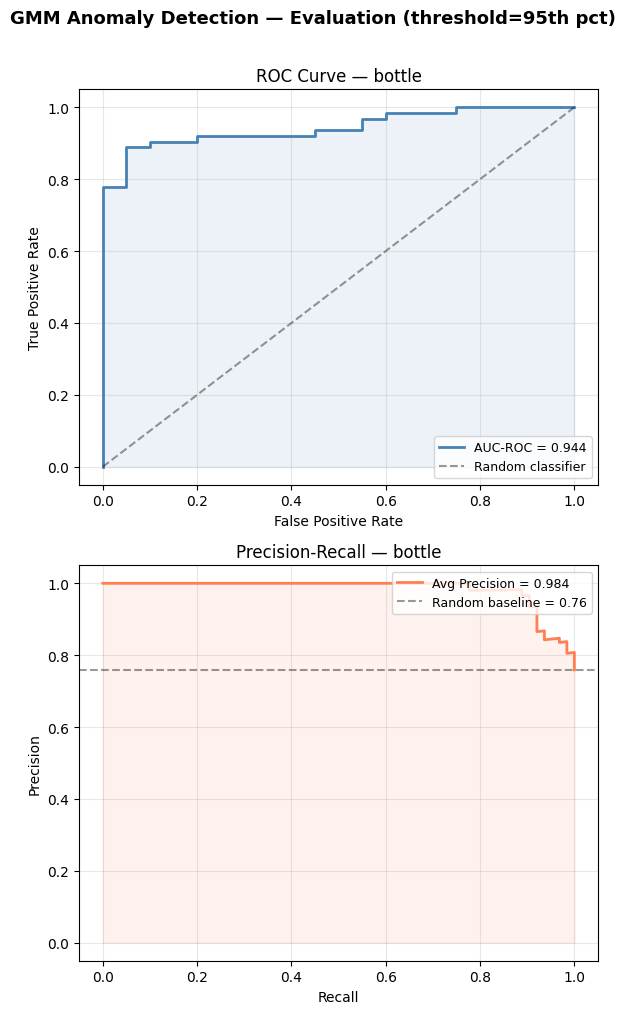

In [27]:
# ── Snippet 9: Full Evaluation ────────────────────────────────────────────────
#
# Evaluates GMM anomaly detection per category using:
#   1. AUC-ROC  — threshold-independent ranking metric (primary)
#   2. Average Precision (AP) — summary of Precision-Recall curve
#   3. Threshold-based metrics — precision, recall, F1 at 95th percentile
#
# Threshold is always derived from TRAINING scores only (no leakage).
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

PERCENTILE = 95   # <-- change to 90 or 99 to experiment

# ─────────────────────────────────────────────────────────────────────────────
# Helper Functions
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_category(cat, score_results, percentile=95):
    """
    Full evaluation for one category.
    Returns dict of all metrics and curve data.
    """
    train_mahal = score_results[cat]['train_mahal']
    test_mahal  = score_results[cat]['test_mahal']
    labels      = score_results[cat]['labels']

    # ── Threshold from training scores only ───────────────────────────────────
    threshold = np.percentile(train_mahal, percentile)

    # ── AUC-ROC ───────────────────────────────────────────────────────────────
    auc_roc     = roc_auc_score(labels, test_mahal)
    fpr, tpr, _ = roc_curve(labels, test_mahal)

    # ── Precision-Recall ──────────────────────────────────────────────────────
    avg_precision        = average_precision_score(labels, test_mahal)
    precision, recall, _ = precision_recall_curve(labels, test_mahal)

    # ── Threshold-based metrics ───────────────────────────────────────────────
    predictions = (test_mahal > threshold).astype(int)
    tp = np.sum((predictions == 1) & (labels == 1))
    tn = np.sum((predictions == 0) & (labels == 0))
    fp = np.sum((predictions == 1) & (labels == 0))
    fn = np.sum((predictions == 0) & (labels == 1))

    prec_t = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec_t  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1     = (2 * prec_t * rec_t / (prec_t + rec_t)
              if (prec_t + rec_t) > 0 else 0)

    return {
        'auc_roc'        : auc_roc,
        'avg_precision'  : avg_precision,
        'fpr'            : fpr,
        'tpr'            : tpr,
        'precision_curve': precision,
        'recall_curve'   : recall,
        'threshold'      : threshold,
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
        'precision'      : prec_t,
        'recall'         : rec_t,
        'f1'             : f1,
        'labels'         : labels
    }


def plot_evaluation_curves(eval_results, categories):
    """
    Plots ROC and PR curves for all selected categories.
    One column per category, two rows (ROC top, PR bottom).
    """
    n_cats = len(categories)
    fig, axes = plt.subplots(2, n_cats, figsize=(6 * n_cats, 10))

    # Handle single category edge case
    if n_cats == 1:
        axes = axes.reshape(2, 1)

    for i, cat in enumerate(categories):
        res      = eval_results[cat]
        baseline = res['labels'].mean()   # random classifier on PR curve

        # ── ROC Curve ─────────────────────────────────────────────────────────
        axes[0, i].plot(res['fpr'], res['tpr'],
                        color='steelblue', linewidth=2,
                        label=f"AUC-ROC = {res['auc_roc']:.3f}")
        axes[0, i].plot([0, 1], [0, 1], 'k--', alpha=0.4,
                        label='Random classifier')
        axes[0, i].fill_between(res['fpr'], res['tpr'],
                                alpha=0.1, color='steelblue')
        axes[0, i].set_xlabel('False Positive Rate')
        axes[0, i].set_ylabel('True Positive Rate')
        axes[0, i].set_title(f'ROC Curve — {cat}')
        axes[0, i].legend(loc='lower right', fontsize=9)
        axes[0, i].grid(True, alpha=0.3)

        # ── PR Curve ──────────────────────────────────────────────────────────
        axes[1, i].plot(res['recall_curve'], res['precision_curve'],
                        color='coral', linewidth=2,
                        label=f"Avg Precision = {res['avg_precision']:.3f}")
        axes[1, i].fill_between(res['recall_curve'],
                                res['precision_curve'],
                                alpha=0.1, color='coral')
        axes[1, i].axhline(y=baseline, color='k', linestyle='--',
                           alpha=0.4,
                           label=f'Random baseline = {baseline:.2f}')
        axes[1, i].set_xlabel('Recall')
        axes[1, i].set_ylabel('Precision')
        axes[1, i].set_title(f'Precision-Recall — {cat}')
        axes[1, i].legend(loc='upper right', fontsize=9)
        axes[1, i].grid(True, alpha=0.3)

    plt.suptitle(
        f'GMM Anomaly Detection — Evaluation (threshold={PERCENTILE}th pct)',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.show()


def print_summary_table(eval_results, categories):
    """Prints a clean summary table of all metrics."""
    print("\n" + "=" * 70)
    print(f"  {'Category':<15} {'AUC-ROC':>8} {'Avg-Prec':>10} "
          f"{'F1':>7} {'Prec':>7} {'Recall':>8}")
    print("=" * 70)
    for cat in categories:
        res = eval_results[cat]
        print(f"  {cat:<15} {res['auc_roc']:>8.3f} "
              f"{res['avg_precision']:>10.3f} "
              f"{res['f1']:>7.3f} "
              f"{res['precision']:>7.3f} "
              f"{res['recall']:>8.3f}")
        print(f"  {'':15} threshold={res['threshold']:.2f}  "
              f"TP={res['tp']}  TN={res['tn']}  "
              f"FP={res['fp']}  FN={res['fn']}")
        print()
    print("=" * 70)

    # Overall average
    avg_auc = np.mean([eval_results[c]['auc_roc'] for c in categories])
    avg_ap  = np.mean([eval_results[c]['avg_precision'] for c in categories])
    avg_f1  = np.mean([eval_results[c]['f1'] for c in categories])
    print(f"  {'AVERAGE':<15} {avg_auc:>8.3f} {avg_ap:>10.3f} {avg_f1:>7.3f}")
    print("=" * 70)


# ─────────────────────────────────────────────────────────────────────────────
# Run Evaluation
# ─────────────────────────────────────────────────────────────────────────────

eval_results = {}

for cat in CATEGORIES:
    eval_results[cat] = evaluate_category(cat, score_results, PERCENTILE)

print_summary_table(eval_results, CATEGORIES)
plot_evaluation_curves(eval_results, CATEGORIES)

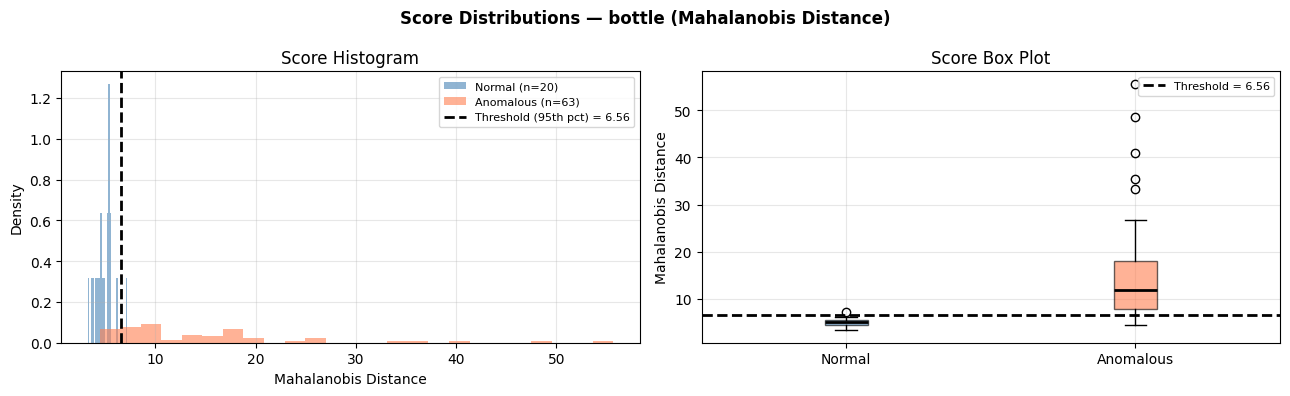

  bottle — Score Summary:
                                 Min     Mean      Max
  Normal                        3.25     4.94     7.20
  Anomalous                     4.44    15.11    87.84
  Threshold (95th pct) : 6.56
  Separation (mean diff)   : 10.17



In [28]:
# ── Snippet 9: Score Distribution Plots ──────────────────────────────────────
#
# Visualizes how well normal and anomalous scores separate.
# This is the visual justification for why threshold-based detection works.
# Shows:
#   - Overlapping histograms (normal vs anomalous)
#   - Box plots (spread + outliers)
#   - Threshold line on histogram
# ─────────────────────────────────────────────────────────────────────────────

PERCENTILE = 95   # must match what you used in Snippet 8 / evaluation

def plot_score_distributions(cat, score_results, percentile=95):
    """
    Plots score distributions for normal vs anomalous test samples.
    Uses Mahalanobis distance as the anomaly score.
    Caps display at 99th percentile to avoid extreme outliers
    crushing the x-axis — does NOT affect actual scores.
    """
    test_mahal  = score_results[cat]['test_mahal']
    train_mahal = score_results[cat]['train_mahal']
    labels      = score_results[cat]['labels']

    normal_scores    = test_mahal[labels == 0]
    anomalous_scores = test_mahal[labels == 1]
    threshold        = np.percentile(train_mahal, percentile)

    # Cap at 99th percentile for display only
    display_cap      = np.percentile(test_mahal, 99)
    normal_disp      = np.clip(normal_scores,    0, display_cap)
    anomalous_disp   = np.clip(anomalous_scores, 0, display_cap)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Score Distributions — {cat} (Mahalanobis Distance)',
                 fontsize=12, fontweight='bold')

    # ── Left: Histogram with threshold line ───────────────────────────────────
    axes[0].hist(normal_disp, bins=25, alpha=0.6, density=True,
                 color='steelblue',
                 label=f'Normal (n={len(normal_scores)})')
    axes[0].hist(anomalous_disp, bins=25, alpha=0.6, density=True,
                 color='coral',
                 label=f'Anomalous (n={len(anomalous_scores)})')
    axes[0].axvline(x=threshold, color='black', linewidth=2,
                    linestyle='--',
                    label=f'Threshold ({percentile}th pct) = {threshold:.2f}')
    axes[0].set_xlabel('Mahalanobis Distance')
    axes[0].set_ylabel('Density')
    axes[0].set_title('Score Histogram')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # ── Right: Box plot ────────────────────────────────────────────────────────
    bp = axes[1].boxplot(
        [normal_disp, anomalous_disp],
        tick_labels=['Normal', 'Anomalous'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2)
    )
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('coral')
    bp['boxes'][1].set_alpha(0.6)
    axes[1].axhline(y=threshold, color='black', linewidth=2,
                    linestyle='--',
                    label=f'Threshold = {threshold:.2f}')
    axes[1].set_ylabel('Mahalanobis Distance')
    axes[1].set_title('Score Box Plot')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── Print separation summary ───────────────────────────────────────────────
    print(f"  {cat} — Score Summary:")
    print(f"  {'':25} {'Min':>8} {'Mean':>8} {'Max':>8}")
    print(f"  {'Normal':25} "
          f"{normal_scores.min():>8.2f} "
          f"{normal_scores.mean():>8.2f} "
          f"{normal_scores.max():>8.2f}")
    print(f"  {'Anomalous':25} "
          f"{anomalous_scores.min():>8.2f} "
          f"{anomalous_scores.mean():>8.2f} "
          f"{anomalous_scores.max():>8.2f}")
    print(f"  Threshold ({percentile}th pct) : {threshold:.2f}")
    print(f"  Separation (mean diff)   : "
          f"{anomalous_scores.mean() - normal_scores.mean():.2f}\n")


# ── Run for all selected categories ───────────────────────────────────────────
for cat in CATEGORIES:
    plot_score_distributions(cat, score_results, PERCENTILE)


  BOTTLE


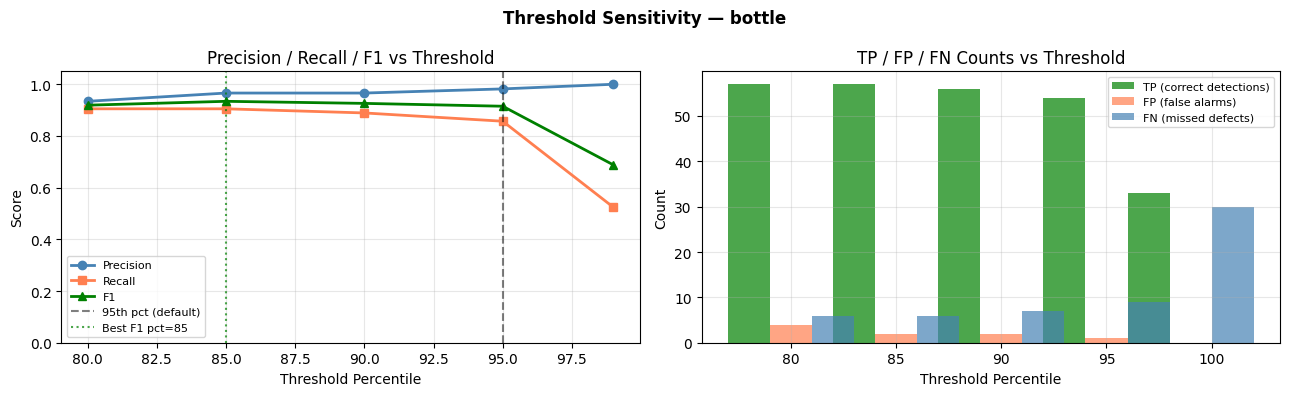


  Threshold Sensitivity Table — bottle
    Pct  Threshold    TP    TN    FP    FN    Prec     Rec      F1
  ------------------------------------------------------------
     80      5.465    57    16     4     6   0.934   0.905   0.919
     85      5.682    57    18     2     6   0.966   0.905   0.934 ◀ best F1
     90      5.984    56    18     2     7   0.966   0.889   0.926
     95      6.561    54    19     1     9   0.982   0.857   0.915
     99      9.725    33    20     0    30   1.000   0.524   0.688

  → Best F1=0.934 at 85th percentile (threshold=5.682)
  → 95th percentile F1=0.915 (our default)



In [29]:
# ── Snippet 10: Threshold Selection Experiment ────────────────────────────────
#
# Compares multiple threshold percentiles to show the precision-recall tradeoff.
# Key insight: higher percentile = fewer false alarms but more missed defects.
# This is the "sensitivity analysis" for your report.
#
# Also plots the full threshold sweep to find the optimal F1 point.
# ─────────────────────────────────────────────────────────────────────────────

PERCENTILES_TO_TEST = [80, 85, 90, 95, 99]

def threshold_experiment(cat, score_results, percentiles):
    """
    Sweeps multiple threshold percentiles and reports metrics for each.
    Also plots F1, Precision, Recall vs percentile.
    Returns a DataFrame summary.
    """
    train_mahal = score_results[cat]['train_mahal']
    test_mahal  = score_results[cat]['test_mahal']
    labels      = score_results[cat]['labels']

    rows = []
    for pct in percentiles:
        threshold   = np.percentile(train_mahal, pct)
        predictions = (test_mahal > threshold).astype(int)

        tp = np.sum((predictions == 1) & (labels == 1))
        tn = np.sum((predictions == 0) & (labels == 0))
        fp = np.sum((predictions == 1) & (labels == 0))
        fn = np.sum((predictions == 0) & (labels == 1))

        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1   = (2 * prec * rec / (prec + rec)
                if (prec + rec) > 0 else 0)

        rows.append({
            'percentile' : pct,
            'threshold'  : round(threshold, 3),
            'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
            'precision'  : round(prec, 3),
            'recall'     : round(rec,  3),
            'f1'         : round(f1,   3)
        })

    df = pd.DataFrame(rows)
    return df


def plot_threshold_experiment(cat, score_results, percentiles):
    """
    Two plots:
      Left  — Precision, Recall, F1 vs threshold percentile
      Right — TP/FP/FN counts vs threshold percentile
    """
    df = threshold_experiment(cat, score_results, percentiles)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Threshold Sensitivity — {cat}',
                 fontsize=12, fontweight='bold')

    # ── Left: Metric curves ───────────────────────────────────────────────────
    axes[0].plot(df['percentile'], df['precision'], 'o-',
                 color='steelblue', linewidth=2, label='Precision')
    axes[0].plot(df['percentile'], df['recall'],    's-',
                 color='coral',     linewidth=2, label='Recall')
    axes[0].plot(df['percentile'], df['f1'],        '^-',
                 color='green',     linewidth=2, label='F1')
    axes[0].axvline(x=95, color='black', linestyle='--',
                    alpha=0.5, label='95th pct (default)')

    best_f1_row = df.loc[df['f1'].idxmax()]
    axes[0].axvline(x=best_f1_row['percentile'], color='green',
                    linestyle=':', alpha=0.7,
                    label=f"Best F1 pct={int(best_f1_row['percentile'])}")

    axes[0].set_xlabel('Threshold Percentile')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Precision / Recall / F1 vs Threshold')
    axes[0].set_ylim(0, 1.05)
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # ── Right: TP / FP / FN counts ────────────────────────────────────────────
    width = 2
    x     = df['percentile']
    axes[1].bar(x - width, df['TP'], width=width, color='green',
                alpha=0.7, label='TP (correct detections)')
    axes[1].bar(x,         df['FP'], width=width, color='coral',
                alpha=0.7, label='FP (false alarms)')
    axes[1].bar(x + width, df['FN'], width=width, color='steelblue',
                alpha=0.7, label='FN (missed defects)')
    axes[1].set_xlabel('Threshold Percentile')
    axes[1].set_ylabel('Count')
    axes[1].set_title('TP / FP / FN Counts vs Threshold')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── Print table ───────────────────────────────────────────────────────────
    print(f"\n  Threshold Sensitivity Table — {cat}")
    print(f"  {'Pct':>5} {'Threshold':>10} {'TP':>5} {'TN':>5} "
          f"{'FP':>5} {'FN':>5} {'Prec':>7} {'Rec':>7} {'F1':>7}")
    print(f"  {'-'*60}")
    for _, row in df.iterrows():
        marker = ' ◀ best F1' if row['f1'] == df['f1'].max() else ''
        print(f"  {int(row['percentile']):>5} "
              f"{row['threshold']:>10.3f} "
              f"{int(row['TP']):>5} {int(row['TN']):>5} "
              f"{int(row['FP']):>5} {int(row['FN']):>5} "
              f"{row['precision']:>7.3f} "
              f"{row['recall']:>7.3f} "
              f"{row['f1']:>7.3f}{marker}")

    best = df.loc[df['f1'].idxmax()]
    print(f"\n  → Best F1={best['f1']:.3f} at "
          f"{int(best['percentile'])}th percentile "
          f"(threshold={best['threshold']:.3f})")
    print(f"  → 95th percentile F1="
          f"{df[df['percentile']==95]['f1'].values[0]:.3f} (our default)\n")

    return df


# ── Run for all selected categories ───────────────────────────────────────────
threshold_dfs = {}

for cat in CATEGORIES:
    print(f"\n{'='*55}")
    print(f"  {cat.upper()}")
    print(f"{'='*55}")
    df = plot_threshold_experiment(cat, score_results, PERCENTILES_TO_TEST)
    threshold_dfs[cat] = df

In [30]:
# ── Snippet 11 (Fixed): Save Results — Appends Across Separate Runs ───────────
#
# Per-category files: always saved in their own subfolder (never overwritten
#                     by a different category)
# Combined file     : appends new categories, updates existing ones
#                     so running bottle then hazelnut gives both rows
# ─────────────────────────────────────────────────────────────────────────────

import os

SAVE_PATH = os.path.join(
    '/content/drive/MyDrive/Zero Shot Anomaly Detection',
    'results', 'gmm'
)
os.makedirs(SAVE_PATH, exist_ok=True)
print(f"Saving results to: {SAVE_PATH}\n")

# ─────────────────────────────────────────────────────────────────────────────
# Save per-category files
# ─────────────────────────────────────────────────────────────────────────────

current_run_rows = []   # metrics from this run only

for cat in CATEGORIES:
    cat_dir = os.path.join(SAVE_PATH, cat)
    os.makedirs(cat_dir, exist_ok=True)

    labels      = score_results[cat]['labels']
    test_mahal  = score_results[cat]['test_mahal']
    test_loglik = score_results[cat]['test_loglik']
    threshold   = eval_results[cat]['threshold']
    predictions = (test_mahal > threshold).astype(int)

    # ── 1. Per-image anomaly scores ───────────────────────────────────────────
    scores_df = pd.DataFrame({
        'category'        : cat,
        'true_label'      : labels,
        'mahal_score'     : test_mahal,
        'loglik_score'    : test_loglik,
        'predicted_label' : predictions,
        'correct'         : (predictions == labels).astype(int)
    })
    scores_df.to_csv(
        os.path.join(cat_dir, 'anomaly_scores.csv'), index=False
    )
    print(f"  [{cat}] anomaly_scores.csv     saved ({len(scores_df)} rows)")

    # ── 2. Metrics summary ────────────────────────────────────────────────────
    res        = eval_results[cat]
    metrics_df = pd.DataFrame([{
        'category'      : cat,
        'method'        : 'GMM',
        'pca_dims'      : PCA_N_COMPONENTS,
        'gmm_k'         : gmm_results[cat]['best_k'],
        'threshold_pct' : PERCENTILE,
        'threshold_val' : round(res['threshold'], 4),
        'auc_roc'       : round(res['auc_roc'], 4),
        'avg_precision' : round(res['avg_precision'], 4),
        'f1'            : round(res['f1'], 4),
        'precision'     : round(res['precision'], 4),
        'recall'        : round(res['recall'], 4),
        'tp'            : res['tp'],
        'tn'            : res['tn'],
        'fp'            : res['fp'],
        'fn'            : res['fn'],
        'n_train'       : len(score_results[cat]['train_mahal']),
        'n_test_normal' : int(np.sum(labels == 0)),
        'n_test_anomaly': int(np.sum(labels == 1))
    }])
    metrics_df.to_csv(
        os.path.join(cat_dir, 'metrics_summary.csv'), index=False
    )
    print(f"  [{cat}] metrics_summary.csv    saved")

    # ── 3. Threshold sweep ────────────────────────────────────────────────────
    sweep_df = threshold_dfs[cat].copy()
    sweep_df.insert(0, 'category', cat)
    sweep_df.to_csv(
        os.path.join(cat_dir, 'threshold_sweep.csv'), index=False
    )
    print(f"  [{cat}] threshold_sweep.csv    saved\n")

    current_run_rows.append(metrics_df)

# ─────────────────────────────────────────────────────────────────────────────
# Smart combine: merge with existing gmm_all_results.csv if it exists
# ─────────────────────────────────────────────────────────────────────────────

combined_path = os.path.join(SAVE_PATH, 'gmm_all_results.csv')

current_run_df = pd.concat(current_run_rows, ignore_index=True)

if os.path.exists(combined_path):
    # Load existing results
    existing_df = pd.read_csv(combined_path)

    # Remove rows for categories in current run (will be replaced with fresh)
    existing_df = existing_df[
        ~existing_df['category'].isin(current_run_df['category'])
    ]

    # Append current run results
    combined_df = pd.concat(
        [existing_df, current_run_df], ignore_index=True
    ).sort_values('category').reset_index(drop=True)

    print(f"  Updated existing gmm_all_results.csv")
    print(f"  Categories now in file: "
          f"{combined_df['category'].tolist()}")
else:
    combined_df = current_run_df
    print(f"  Created new gmm_all_results.csv")

combined_df.to_csv(combined_path, index=False)

# ─────────────────────────────────────────────────────────────────────────────
# Final summary printout
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'='*55}")
print(f"  gmm_all_results.csv — Full Contents")
print(f"{'='*55}")
print(combined_df[['category', 'auc_roc', 'avg_precision',
                   'f1', 'precision', 'recall']].to_string(index=False))
print(f"{'='*55}")
print(f"\n  This run processed   : {CATEGORIES}")
print(f"  Total in combined CSV: {len(combined_df)} categorie(s)")
print(f"\n  Folder structure saved:")
for cat in CATEGORIES:
    print(f"    results/gmm/{cat}/")
    print(f"      ├── anomaly_scores.csv")
    print(f"      ├── metrics_summary.csv")
    print(f"      └── threshold_sweep.csv")
print(f"    results/gmm/gmm_all_results.csv  ← combined")

Saving results to: /content/drive/MyDrive/Zero Shot Anomaly Detection/results/gmm

  [bottle] anomaly_scores.csv     saved (83 rows)
  [bottle] metrics_summary.csv    saved
  [bottle] threshold_sweep.csv    saved

  Created new gmm_all_results.csv

  gmm_all_results.csv — Full Contents
category  auc_roc  avg_precision     f1  precision  recall
  bottle   0.9437         0.9838 0.9153     0.9818  0.8571

  This run processed   : ['bottle']
  Total in combined CSV: 1 categorie(s)

  Folder structure saved:
    results/gmm/bottle/
      ├── anomaly_scores.csv
      ├── metrics_summary.csv
      └── threshold_sweep.csv
    results/gmm/gmm_all_results.csv  ← combined
